In [1]:
from google.colab import files
uploaded = files.upload()


Saving CMAPSSData.zip to CMAPSSData.zip


In [2]:
import zipfile, os

zip_path = next(iter(uploaded))
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("data")

os.listdir("data")


['RUL_FD001.txt',
 'Damage Propagation Modeling.pdf',
 'train_FD001.txt',
 'RUL_FD004.txt',
 'RUL_FD002.txt',
 'train_FD003.txt',
 'train_FD002.txt',
 'test_FD004.txt',
 'test_FD001.txt',
 'readme.txt',
 'test_FD003.txt',
 'test_FD002.txt',
 'RUL_FD003.txt',
 'train_FD004.txt']

In [3]:
!pip install torch torchvision torchaudio --quiet

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [4]:
TRAIN_PATH = "data/train_FD003.txt"
TEST_PATH  = "data/test_FD003.txt"
RUL_PATH   = "data/RUL_FD003.txt"

SEQ_LEN = 30
STEP = 1
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 100
PATIENCE = 10
RUL_CLIP = 125   # same as FD001, FD003 single-condition

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


In [5]:
train_df = pd.read_csv(TRAIN_PATH, sep=" ", header=None).dropna(axis=1, how="all")
test_df  = pd.read_csv(TEST_PATH,  sep=" ", header=None).dropna(axis=1, how="all")
rul_df   = pd.read_csv(RUL_PATH,   sep=" ", header=None)

cols = ["unit", "cycle"] + [f"op_setting_{i}" for i in range(1,4)] + [f"sensor_{i}" for i in range(1,22)]
train_df = train_df.iloc[:, :len(cols)]
test_df  = test_df.iloc[:, :len(cols)]
train_df.columns = cols
test_df.columns  = cols


In [6]:
train_max = train_df.groupby("unit")["cycle"].max().to_dict()
train_df["RUL"] = train_df.apply(lambda r: train_max[r["unit"]] - r["cycle"], axis=1)
train_df["RUL"] = train_df["RUL"].clip(upper=RUL_CLIP)

test_rul_map = {uid: int(r) for uid, r in zip(sorted(test_df["unit"].unique()), rul_df[0])}


In [7]:
selected_features = [
    "op_setting_1","op_setting_2","op_setting_3",
    "sensor_2","sensor_3","sensor_4","sensor_7","sensor_8",
    "sensor_9","sensor_11","sensor_12","sensor_13","sensor_14","sensor_15"
]

train_df = train_df[["unit","cycle"] + selected_features + ["RUL"]]
test_df  = test_df [["unit","cycle"] + selected_features]

scaler = StandardScaler()
train_df[selected_features] = scaler.fit_transform(train_df[selected_features])
test_df[selected_features]  = scaler.transform(test_df[selected_features])


In [8]:
def make_sequences(df, units, seq_len):
    X, y = [], []
    for uid in units:
        temp = df[df["unit"] == uid].reset_index(drop=True)
        feats = temp[selected_features].values
        rul   = temp["RUL"].values
        L = len(temp)

        for i in range(0, L - seq_len + 1, STEP):
            X.append(feats[i:i+seq_len])
            y.append(rul[i+seq_len-1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

units = sorted(train_df["unit"].unique())
train_units = units[:80]      # FD003 same engine count as FD001
val_units = units[80:]

X_train, y_train = make_sequences(train_df, train_units, SEQ_LEN)
X_val,   y_val   = make_sequences(train_df, val_units,   SEQ_LEN)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(17459, 30, 14) (17459,)
(4361, 30, 14) (4361,)


In [9]:
def make_test_windows(df, rul_map, seq_len):
    X, y = [], []
    units = sorted(df["unit"].unique())

    for uid in units:
        temp = df[df["unit"] == uid].reset_index(drop=True)
        feats = temp[selected_features].values

        if len(feats) < seq_len:
            pad = np.repeat(feats[0:1], seq_len - len(feats), axis=0)
            feats = np.vstack([pad, feats])
        else:
            feats = feats[-seq_len:]

        X.append(feats)
        y.append(min(rul_map[uid], RUL_CLIP))

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), units

X_test, y_test, test_units = make_test_windows(test_df, test_rul_map, SEQ_LEN)


In [10]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader  = DataLoader(SeqDataset(X_test, y_test), batch_size=BATCH_SIZE)


In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_dim=len(selected_features), hidden=64):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUModel().to(DEVICE)
print(model)


GRUModel(
  (gru): GRU(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [12]:
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

best_val, wait = float("inf"), 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(Xb), yb).item()

    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train={tr_loss:.4f} | Val={val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_fd003_gru.pth")
        torch.save(scaler, "scaler_fd003.pkl")
        print("Saved best model + scaler")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping!")
            break

print("Training completed.")


Epoch 001 | Train=14508.8405 | Val=842.1990
Saved best model + scaler
Epoch 002 | Train=3829.2223 | Val=683.5980
Saved best model + scaler
Epoch 003 | Train=3455.5038 | Val=606.4154
Saved best model + scaler
Epoch 004 | Train=3319.2449 | Val=655.4337
Epoch 005 | Train=3229.2071 | Val=568.5670
Saved best model + scaler
Epoch 006 | Train=3197.3678 | Val=649.8071
Epoch 007 | Train=3117.2489 | Val=559.8774
Saved best model + scaler
Epoch 008 | Train=3102.7082 | Val=554.5126
Saved best model + scaler
Epoch 009 | Train=3049.3189 | Val=605.5189
Epoch 010 | Train=3034.3406 | Val=535.9701
Saved best model + scaler
Epoch 011 | Train=3015.1880 | Val=638.9478
Epoch 012 | Train=3007.3151 | Val=598.5811
Epoch 013 | Train=2981.5144 | Val=589.3980
Epoch 014 | Train=2919.3970 | Val=519.2173
Saved best model + scaler
Epoch 015 | Train=2901.2260 | Val=666.4988
Epoch 016 | Train=2851.0528 | Val=550.6630
Epoch 017 | Train=2871.7906 | Val=545.8271
Epoch 018 | Train=2819.0213 | Val=560.2037
Epoch 019 | Train

In [13]:
best_model = GRUModel().to(DEVICE)
best_model.load_state_dict(torch.load("best_fd003_gru.pth"))
best_model.eval()

print("FD003 Model Loaded!")


FD003 Model Loaded!


In [14]:
preds = []
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(DEVICE)
        preds.extend(best_model(Xb).cpu().numpy().flatten())

preds = np.array(preds)

rmse = math.sqrt(mean_squared_error(y_test, preds))
print("FD003 TEST RMSE =", round(rmse, 3))


FD003 TEST RMSE = 14.366


In [16]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_pred = model(X_test_tensor).cpu().numpy().flatten()


In [17]:
engine_ids = test_df["unit"].unique()
cycles = test_df.groupby("unit")["cycle"].max().values

fd003_results = pd.DataFrame({
    "Engine_ID": engine_ids,
    "Final_Cycle": cycles,
    "Actual_RUL": y_test.flatten(),
    "Predicted_RUL": y_pred
})


In [18]:
fd003_results.head()


,Engine_ID,Final_Cycle,Actual_RUL,Predicted_RUL
0,1,233,44.0,44.657505
1,2,124,51.0,59.370060
2,3,234,27.0,33.229443
3,4,68,120.0,122.083534
4,5,138,101.0,120.325439


In [19]:
def assign_alert(rul):
    if rul > 50:
        return "SAFE"
    elif rul > 20:
        return "WARNING"
    else:
        return "CRITICAL"


In [20]:
fd003_results["Alert"] = fd003_results["Predicted_RUL"].apply(assign_alert)


In [22]:
fd003_results.head()

,Engine_ID,Final_Cycle,Actual_RUL,Predicted_RUL,Alert
0,1,233,44.0,44.657505,WARNING
1,2,124,51.0,59.370060,SAFE
2,3,234,27.0,33.229443,WARNING
3,4,68,120.0,122.083534,SAFE
4,5,138,101.0,120.325439,SAFE


In [21]:
fd003_results["Alert"].value_counts()


,count
Alert,
SAFE,71
WARNING,17
CRITICAL,12


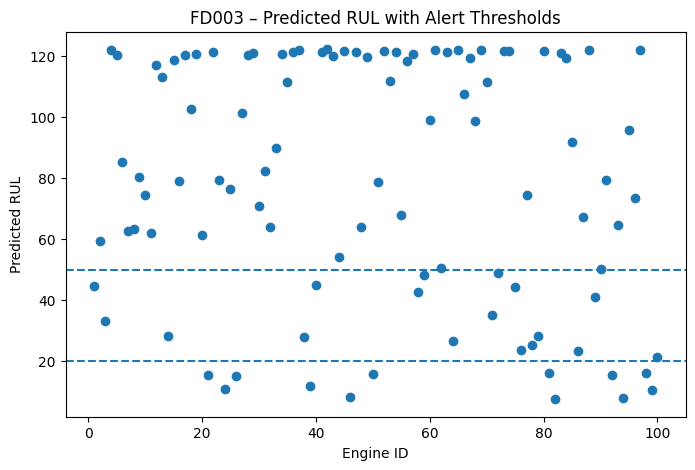

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(fd003_results["Engine_ID"], fd003_results["Predicted_RUL"])
plt.axhline(50, linestyle="--")
plt.axhline(20, linestyle="--")
plt.xlabel("Engine ID")
plt.ylabel("Predicted RUL")
plt.title("FD003 – Predicted RUL with Alert Thresholds")
plt.show()


In [24]:
fd003_results.to_csv("fd003_rul_alert_results.csv", index=False)


In [25]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir "/content/drive/MyDrive/FD003_GRU"

!cp best_fd003_gru.pth /content/drive/MyDrive/FD003_GRU/
!cp scaler_fd003.pkl   /content/drive/MyDrive/FD003_GRU/

print("FD003 saved permanently!")


Mounted at /content/drive
mkdir: cannot create directory ‘/content/drive/MyDrive/FD003_GRU’: File exists
FD003 saved permanently!


In [26]:
model = GRUModel().to(DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/FD003_GRU/best_fd003_gru.pth",
                                 map_location=DEVICE))
model.eval()

scaler = torch.load("/content/drive/MyDrive/FD003_GRU/scaler_fd003.pkl", weights_only=False)

print("FD003 future model loaded!")


FD003 future model loaded!


In [27]:
def predict_future_rul(df, seq_len=SEQ_LEN):
    df[selected_features] = scaler.transform(df[selected_features])

    window = df[selected_features].values[-seq_len:]
    if len(window) < seq_len:
        pad = np.repeat(window[0:1], seq_len - len(window), axis=0)
        window = np.vstack([pad, window])

    x = torch.tensor(window[np.newaxis,:,:], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred = model(x).item()
    return pred


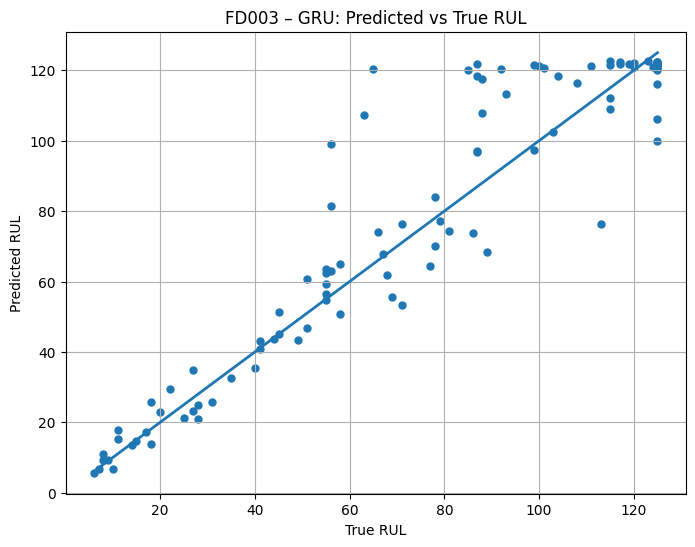

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, s=25)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("FD003 – GRU: Predicted vs True RUL")
plt.grid(True)
plt.show()


In [29]:
mse = mean_squared_error(y_test, preds)
rmse = math.sqrt(mse)
print("FD003 GRU RMSE:", round(rmse, 3))


FD003 GRU RMSE: 14.366


In [ ]:
plt.figure(figsize=(10,6))

sorted_idx = y_test.argsort()
plt.plot(y_test[sorted_idx], label="True RUL")
plt.plot(preds[sorted_idx], label="Predicted RUL")

plt.title("FD003 – GRU Actual vs Predicted RUL Trend")
plt.xlabel("Engine (sorted by true RUL)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import os

output_dir = "/content/drive/MyDrive/CMAPSS"
os.makedirs(output_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(output_dir, "GRU_FD003.pth"))

print("FD003 GRU model saved!")
